In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import numpy as np
import matplotlib.pyplot as plt

/home/BTECH_7TH_SEM/Desktop/MML-RL-and-NLP/MML/mml-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class VQADataset(Dataset):
    def __init__(self, num_samples=500, max_len=16):
        self.num_samples = num_samples
        self.max_len = max_len
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        question = "What is in the image?"
        encoding = self.tokenizer(question, return_tensors="pt", padding="max_length", truncation=True, max_length=self.max_len)
        text_inputs = {k: v.squeeze(0) for k, v in encoding.items()}
        image_feature = torch.randn(2048)
        label = torch.tensor(np.random.randint(0, 10))
        return text_inputs, image_feature, label

In [3]:
class VisualBERT(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.img_fc = nn.Linear(2048, 768)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, text_inputs, img_feats):
        text_outputs = self.text_encoder(**text_inputs)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        img_emb = self.img_fc(img_feats)
        fused = text_cls + img_emb
        return self.classifier(fused)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(VQADataset(300), batch_size=16, shuffle=True)
val_loader = DataLoader(VQADataset(50), batch_size=16)

model = VisualBERT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 200

In [9]:
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for text_inputs, img_feats, labels in train_loader:
        text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
        img_feats, labels = img_feats.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_inputs, img_feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for text_inputs, img_feats, labels in val_loader:
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            img_feats, labels = img_feats.to(device), labels.to(device)
            outputs = model(text_inputs, img_feats)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)
    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Acc {train_accs[-1]:.2f}, Val {val_losses[-1]:.4f}, Acc {val_accs[-1]:.2f}")

Epoch 1: Train 2.4125, Acc 0.09, Val 2.3101, Acc 0.10
Epoch 2: Train 2.3831, Acc 0.11, Val 2.2190, Acc 0.16
Epoch 3: Train 2.3884, Acc 0.10, Val 2.3017, Acc 0.12
Epoch 4: Train 2.4080, Acc 0.07, Val 2.3237, Acc 0.12
Epoch 5: Train 2.3585, Acc 0.11, Val 2.4087, Acc 0.02
Epoch 6: Train 2.4215, Acc 0.11, Val 2.5170, Acc 0.16
Epoch 7: Train 2.3806, Acc 0.11, Val 2.4616, Acc 0.12
Epoch 8: Train 2.3504, Acc 0.11, Val 2.4235, Acc 0.06
Epoch 9: Train 2.3710, Acc 0.10, Val 2.2799, Acc 0.08
Epoch 10: Train 2.4057, Acc 0.07, Val 2.4115, Acc 0.10
Epoch 11: Train 2.4313, Acc 0.09, Val 2.4793, Acc 0.14
Epoch 12: Train 2.3928, Acc 0.10, Val 2.4552, Acc 0.20
Epoch 13: Train 2.3990, Acc 0.11, Val 2.3735, Acc 0.08
Epoch 14: Train 2.3703, Acc 0.12, Val 2.4189, Acc 0.10
Epoch 15: Train 2.4209, Acc 0.08, Val 2.2806, Acc 0.14
Epoch 16: Train 2.3642, Acc 0.14, Val 2.4277, Acc 0.12
Epoch 17: Train 2.4012, Acc 0.10, Val 2.4203, Acc 0.12
Epoch 18: Train 2.3740, Acc 0.11, Val 2.4300, Acc 0.10
Epoch 19: Train 2.4

In [6]:
sample_text, sample_img, _ = VQADataset()[0]
sample_text = {k: v.unsqueeze(0).to(device) for k, v in sample_text.items()}
sample_img = sample_img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = model(sample_text, sample_img)
    pred_class = torch.argmax(pred, dim=1).item()

print("Predicted class:", pred_class)

Predicted class: 8


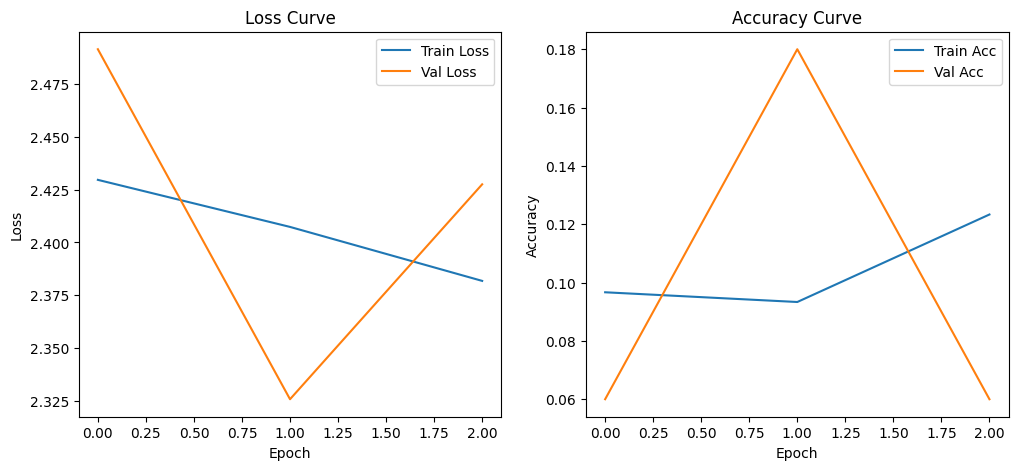

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()